# LSTM Many-to-Many Next-Token Evaluation

Оценка улучшенной LSTM из Checkpoint 6. В отличие от baseline LSTM, модель предсказывает следующий `event_id` для каждой позиции окна:

```text
[e1, e2, ..., e10] -> [e2, e3, ..., e11]
```

Аномальность блока считается через долю позиций, где настоящий next-token не попал в top-k предсказаний модели.

### Импорты

In [14]:
import sys
import json

from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import average_precision_score, precision_recall_curve

cwd = Path.cwd().resolve()
if (cwd / "FastAPI").exists():
    CHECKPOINT_DIR = cwd
elif cwd.name == "notebooks" and (cwd.parent / "FastAPI").exists():
    CHECKPOINT_DIR = cwd.parent
else:
    CHECKPOINT_DIR = cwd / "Checkpoint_6"

sys.path.insert(0, str(CHECKPOINT_DIR / "FastAPI"))

from model.lstm_token_model import LSTMNextTokenModel
from model.lstm_token_metrics import (
    block_confusion_from_ratio_map,
    block_token_anomaly_ratio_map,
    predict_token_topk_miss,
    sweep_token_thresholds,
)

plt.style.use("default")
CHECKPOINT_DIR

PosixPath('/Users/andrew/PycharmProjects/anomaly-detection-distributed-clouds/Checkpoint_6')

### Пути и загрузка данных

In [15]:
DATA_PATH = CHECKPOINT_DIR / "data" / "preprocessed" / "token_seq_out" / "hdfs_token_sequence_data.npz"
META_PATH = CHECKPOINT_DIR / "data" / "preprocessed" / "token_seq_out" / "hdfs_token_sequence_meta.json"
MODEL_PATH = CHECKPOINT_DIR / "FastAPI" / "model" / "lstm_token_model.pt"
HISTORY_PATH = CHECKPOINT_DIR / "experiments" / "lstm_token_model.history.json"

for path in [DATA_PATH, META_PATH, MODEL_PATH, HISTORY_PATH]:
    if not path.exists():
        raise FileNotFoundError(path)

data = np.load(DATA_PATH, allow_pickle=True)
x_train = data["X_train"]
y_train = data["Y_train"]
x_val = data["X_val"]
y_val = data["Y_val"]
x_test = data["X_test"]
y_test = data["Y_test"]
val_labels = data["val_labels"]
val_block_ids = data["val_block_ids"]
test_labels = data["test_labels"]
test_block_ids = data["test_block_ids"]

meta = json.loads(META_PATH.read_text(encoding="utf-8"))

print("Train windows:", x_train.shape, y_train.shape)
print("Val windows:  ", x_val.shape, y_val.shape)
print("Test windows: ", x_test.shape, y_test.shape)
print("Vocab size:", meta.get("event_vocab_size"))
print("Window size:", meta.get("window_size"))

Train windows: (4242856, 10) (4242856, 10)
Val windows:   (579655, 10) (579655, 10)
Test windows:  (645520, 10) (645520, 10)
Vocab size: 20
Window size: 10


### Загрузка модели

In [17]:
ckpt = torch.load(MODEL_PATH, map_location="cpu")
config = ckpt.get("config", {})
vocab_size = int(ckpt["vocab_size"])

model = LSTMNextTokenModel(
    vocab_size=vocab_size,
    embedding_dim=int(config.get("embedding_dim", 32)),
    hidden_size=int(config.get("hidden_size", 64)),
    num_layers=int(config.get("num_layers", 1)),
    dropout=float(config.get("dropout", 0.0)),
)
model.load_state_dict(ckpt["state_dict"])

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()

config

{'embedding_dim': 32,
 'hidden_size': 64,
 'num_layers': 1,
 'dropout': 0.0,
 'top_k': 3,
 'anomaly_ratio_threshold': 8.089428988370027,
 'device': 'cpu',
 'objective': 'many_to_many_next_token',
 'scoring': 'nll_max',
 'anomaly_score_threshold': 8.089428988370027}

### Инференс и block-level scores

In [18]:
top_k = int(config.get("top_k", 3))
default_thr = float(config.get("anomaly_ratio_threshold", history["threshold"][-1]))
batch_size = 4096

val_miss = predict_token_topk_miss(model, x_val, y_val, device, top_k, batch_size=batch_size)
test_miss = predict_token_topk_miss(model, x_test, y_test, device, top_k, batch_size=batch_size)

val_ratio_map = block_token_anomaly_ratio_map(val_miss, val_block_ids)
test_ratio_map = block_token_anomaly_ratio_map(test_miss, test_block_ids)

val_label_map = {str(bid): int(lbl) for bid, lbl in zip(val_block_ids, val_labels)}
test_label_map = {str(bid): int(lbl) for bid, lbl in zip(test_block_ids, test_labels)}

def ratio_arrays(ratio_map, label_map):
    block_ids = np.array(list(ratio_map.keys()), dtype=str)
    ratios = np.array([ratio_map[bid] for bid in block_ids], dtype=float)
    labels = np.array([label_map.get(bid, 0) for bid in block_ids], dtype=int)
    return block_ids, ratios, labels

val_blocks, val_ratios, val_block_labels = ratio_arrays(val_ratio_map, val_label_map)
test_blocks, test_ratios, test_block_labels = ratio_arrays(test_ratio_map, test_label_map)

print("top_k:", top_k)
print("threshold:", default_thr)
print("Val blocks:", len(val_blocks), "anomaly blocks:", int(val_block_labels.sum()))
print("Test blocks:", len(test_blocks), "anomaly blocks:", int(test_block_labels.sum()))

top_k: 3
threshold: 8.089428988370027
Val blocks: 58989 anomaly blocks: 3167
Test blocks: 63303 anomaly blocks: 7480


### Confusion matrix и основные метрики

Confusion matrix (test):
 TP: 0  FP: 0
 FN: 7480  TN: 55823

Precision:        0.000
Recall:           0.000
F1:               0.000
FPR:              0.000
Average Precision:0.661


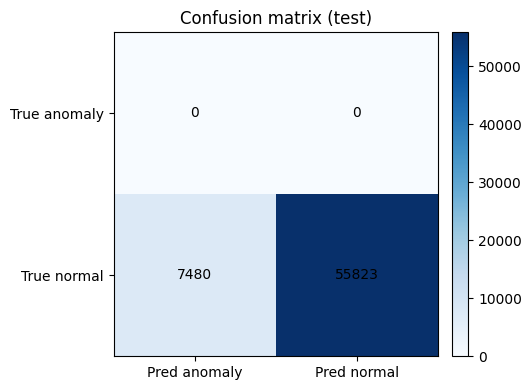

In [19]:
def confusion_metrics(tp, fp, tn, fn):
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    fpr = fp / (fp + tn) if (fp + tn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return precision, recall, fpr, f1

tp, fp, tn, fn = block_confusion_from_ratio_map(test_ratio_map, test_label_map, default_thr)
precision, recall, fpr, f1 = confusion_metrics(tp, fp, tn, fn)
ap = average_precision_score(test_block_labels, test_ratios)

print("Confusion matrix (test):")
print(f" TP: {tp}  FP: {fp}")
print(f" FN: {fn}  TN: {tn}")
print()
print(f"Precision:        {precision:.3f}")
print(f"Recall:           {recall:.3f}")
print(f"F1:               {f1:.3f}")
print(f"FPR:              {fpr:.3f}")
print(f"Average Precision:{ap:.3f}")

cm = np.array([[tp, fp], [fn, tn]])
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1], labels=["Pred anomaly", "Pred normal"])
ax.set_yticks([0, 1], labels=["True anomaly", "True normal"])
ax.set_title("Confusion matrix (test)")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

### Precision/Recall/F1 и FPR при изменении порога

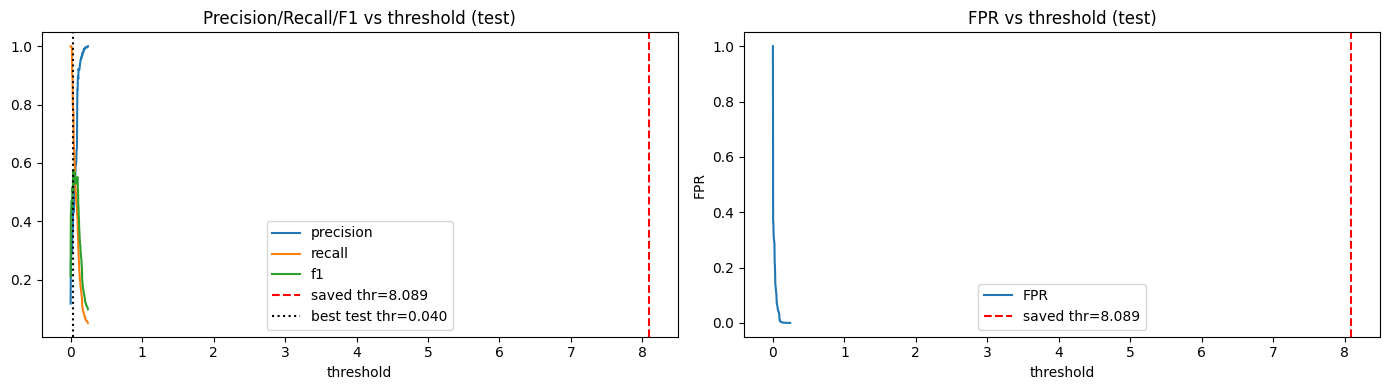

Best test threshold by F1: 0.0398
Best test F1: 0.5762


In [20]:
max_thr = float(np.quantile(test_ratios, 0.995)) if test_ratios.size else 0.5
thresholds = np.linspace(0.0, max(0.2, max_thr), 80)

sweep = sweep_token_thresholds(test_ratio_map, test_label_map, thresholds)
thr_vals = np.array([row[0] for row in sweep])
prec_vals = np.array([row[1] for row in sweep])
rec_vals = np.array([row[2] for row in sweep])
f1_vals = np.array([row[3] for row in sweep])

fpr_vals = []
for t in thr_vals:
    tp_t, fp_t, tn_t, fn_t = block_confusion_from_ratio_map(test_ratio_map, test_label_map, float(t))
    fpr_vals.append(fp_t / (fp_t + tn_t) if (fp_t + tn_t) else 0.0)
fpr_vals = np.array(fpr_vals)

best_idx = int(np.argmax(f1_vals))
best_thr = float(thr_vals[best_idx])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(thr_vals, prec_vals, label="precision")
axes[0].plot(thr_vals, rec_vals, label="recall")
axes[0].plot(thr_vals, f1_vals, label="f1")
axes[0].axvline(default_thr, color="red", linestyle="--", label=f"saved thr={default_thr:.3f}")
axes[0].axvline(best_thr, color="black", linestyle=":", label=f"best test thr={best_thr:.3f}")
axes[0].set_title("Precision/Recall/F1 vs threshold (test)")
axes[0].set_xlabel("threshold")
axes[0].legend()

axes[1].plot(thr_vals, fpr_vals, label="FPR")
axes[1].axvline(default_thr, color="red", linestyle="--", label=f"saved thr={default_thr:.3f}")
axes[1].set_title("FPR vs threshold (test)")
axes[1].set_xlabel("threshold")
axes[1].set_ylabel("FPR")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Best test threshold by F1: {best_thr:.4f}")
print(f"Best test F1: {f1_vals[best_idx]:.4f}")

### Альтернативные anomaly scores

Many-to-many модель выдаёт предсказания для каждой позиции окна. Поэтому есть несколько способов агрегировать ошибку в score блока:

- `topk_all`: доля miss по всем позициям окна
- `topk_last`: miss только по последней позиции окна, ближе к baseline `T+1`
- `topk_last3`: miss только по последним 3 позициям окна
- `nll_mean`: средний `-log P(true_token)` по позициям
- `nll_p95`: 95-й перцентиль NLL по позициям
- `nll_max`: максимальный NLL по позициям

NLL полезен тем, что учитывает не только факт промаха top-k, но и насколько низкой была вероятность правильного next-token.

In [21]:
def predict_token_nll(model, x, y, device, batch_size=4096):
    model.eval()
    if x.size == 0:
        return np.empty((0, 0), dtype=float)
    nll_batches = []
    with torch.no_grad():
        for i in range(0, len(x), batch_size):
            xb = torch.tensor(x[i : i + batch_size], dtype=torch.long, device=device)
            yb = torch.tensor(y[i : i + batch_size], dtype=torch.long, device=device)
            logits = model(xb)
            log_probs = torch.log_softmax(logits, dim=-1)
            nll = -log_probs.gather(dim=-1, index=yb.unsqueeze(-1)).squeeze(-1)
            nll_batches.append(nll.cpu().numpy())
    return np.concatenate(nll_batches, axis=0)


def block_score_map_from_matrix(score_matrix, block_ids, agg="mean", positions="all"):
    block_ids = block_ids.astype(str)
    if positions == "last":
        score_matrix = score_matrix[:, -1:]
    elif isinstance(positions, int):
        score_matrix = score_matrix[:, -positions:]
    elif positions != "all":
        raise ValueError(f"Unsupported positions={positions}")

    block_to_values = {}
    for bid, row in zip(block_ids, score_matrix):
        block_to_values.setdefault(bid, []).append(np.asarray(row, dtype=float))

    result = {}
    for bid, rows in block_to_values.items():
        values = np.concatenate(rows)
        if agg == "mean":
            result[bid] = float(values.mean())
        elif agg == "p95":
            result[bid] = float(np.quantile(values, 0.95))
        elif agg == "max":
            result[bid] = float(values.max())
        else:
            raise ValueError(f"Unsupported agg={agg}")
    return result


def best_threshold_by_f1(ratio_map, label_map, num=100):
    scores = np.array(list(ratio_map.values()), dtype=float)
    if scores.size == 0:
        return 0.0, 0.0, 0.0, 0.0
    max_thr = float(np.quantile(scores, 0.995))
    thresholds = np.linspace(0.0, max(max_thr, float(scores.max()), 1e-9), num)
    sweep = sweep_token_thresholds(ratio_map, label_map, thresholds)
    best = max(sweep, key=lambda row: row[3])
    return best


def metrics_at_threshold(ratio_map, label_map, threshold):
    tp, fp, tn, fn = block_confusion_from_ratio_map(ratio_map, label_map, threshold)
    precision, recall, fpr, f1 = confusion_metrics(tp, fp, tn, fn)
    return {
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
        "precision": precision,
        "recall": recall,
        "fpr": fpr,
        "f1": f1,
    }


def labels_scores_arrays(score_map, label_map):
    block_ids = np.array(list(score_map.keys()), dtype=str)
    scores = np.array([score_map[bid] for bid in block_ids], dtype=float)
    labels = np.array([label_map.get(bid, 0) for bid in block_ids], dtype=int)
    return labels, scores

val_nll = predict_token_nll(model, x_val, y_val, device, batch_size=batch_size)
test_nll = predict_token_nll(model, x_test, y_test, device, batch_size=batch_size)

score_specs = [
    ("topk_all", val_miss, test_miss, "mean", "all"),
    ("topk_last", val_miss, test_miss, "mean", "last"),
    ("topk_last3", val_miss, test_miss, "mean", 3),
    ("nll_mean", val_nll, test_nll, "mean", "all"),
    ("nll_p95", val_nll, test_nll, "p95", "all"),
    ("nll_max", val_nll, test_nll, "max", "all"),
]

score_results = []
score_maps = {}
for name, val_matrix, test_matrix, agg, positions in score_specs:
    val_score_map = block_score_map_from_matrix(val_matrix, val_block_ids, agg=agg, positions=positions)
    test_score_map = block_score_map_from_matrix(test_matrix, test_block_ids, agg=agg, positions=positions)
    score_maps[name] = {"val": val_score_map, "test": test_score_map}

    val_thr, val_p, val_r, val_f1_best = best_threshold_by_f1(val_score_map, val_label_map)
    test_metrics_val_thr = metrics_at_threshold(test_score_map, test_label_map, val_thr)
    test_thr, test_p_best, test_r_best, test_f1_best = best_threshold_by_f1(test_score_map, test_label_map)
    test_labels_for_ap, test_scores_for_ap = labels_scores_arrays(test_score_map, test_label_map)
    ap_score = average_precision_score(test_labels_for_ap, test_scores_for_ap)

    score_results.append(
        {
            "score": name,
            "val_best_thr": val_thr,
            "val_best_f1": val_f1_best,
            "test_f1_at_val_thr": test_metrics_val_thr["f1"],
            "test_precision_at_val_thr": test_metrics_val_thr["precision"],
            "test_recall_at_val_thr": test_metrics_val_thr["recall"],
            "test_fpr_at_val_thr": test_metrics_val_thr["fpr"],
            "test_best_thr": test_thr,
            "test_best_f1": test_f1_best,
            "test_ap": ap_score,
        }
    )

score_results

[{'score': 'topk_all',
  'val_best_thr': 0.09696969696969697,
  'val_best_f1': 0.5207591933570581,
  'test_f1_at_val_thr': 0.5492753623188406,
  'test_precision_at_val_thr': 0.851685393258427,
  'test_recall_at_val_thr': 0.4053475935828877,
  'test_fpr_at_val_thr': 0.009458466940150118,
  'test_best_thr': 0.038720538720538725,
  'test_best_f1': 0.5757560709142374,
  'test_ap': 0.6606541974181501},
 {'score': 'topk_last',
  'val_best_thr': 0.09090909090909091,
  'val_best_f1': 0.6675919500346982,
  'test_f1_at_val_thr': 0.7700585751260045,
  'test_precision_at_val_thr': 0.7849208553179672,
  'test_recall_at_val_thr': 0.7557486631016043,
  'test_fpr_at_val_thr': 0.027748419110402524,
  'test_best_thr': 0.09090909090909091,
  'test_best_f1': 0.7700585751260045,
  'test_ap': 0.7674641626598667},
 {'score': 'topk_last3',
  'val_best_thr': 0.09090909090909091,
  'val_best_f1': 0.5191197128141096,
  'test_f1_at_val_thr': 0.6115024382692159,
  'test_precision_at_val_thr': 0.7262364405221549,
 

In [22]:
score_df = pd.DataFrame(score_results)
display(score_df.sort_values("test_f1_at_val_thr", ascending=False))

best_by_val_thr = max(score_results, key=lambda item: item["test_f1_at_val_thr"])
best_score_name = best_by_val_thr["score"]
print("Best scoring by test F1 at validation-selected threshold:", best_score_name)
print(best_by_val_thr)

,score,val_best_thr,val_best_f1,test_f1_at_val_thr,test_precision_at_val_thr,test_recall_at_val_thr,test_fpr_at_val_thr,test_best_thr,test_best_f1,test_ap
5,nll_max,8.089429,0.890069,0.916597,0.959772,0.877139,0.004926,7.882048,0.914863,0.975298
1,topk_last,0.090909,0.667592,0.770059,0.784921,0.755749,0.027748,0.090909,0.770059,0.767464
2,topk_last3,0.090909,0.519120,0.611502,0.726236,0.528075,0.026674,0.030303,0.705625,0.721618
4,nll_p95,5.870862,0.602689,0.603944,0.933968,0.446257,0.004228,5.739031,0.606148,0.642459
3,nll_mean,0.980164,0.530743,0.569968,0.836091,0.432353,0.011357,0.775450,0.609432,0.703752
0,topk_all,0.096970,0.520759,0.549275,0.851685,0.405348,0.009458,0.038721,0.575756,0.660654


Best scoring by test F1 at validation-selected threshold: nll_max
{'score': 'nll_max', 'val_best_thr': 8.089428988370027, 'val_best_f1': 0.8900692097215517, 'test_f1_at_val_thr': 0.9165968147527243, 'test_precision_at_val_thr': 0.9597717963721475, 'test_recall_at_val_thr': 0.8771390374331551, 'test_fpr_at_val_thr': 0.00492628486466152, 'test_best_thr': 7.8820477109966856, 'test_best_f1': 0.9148625130525583, 'test_ap': 0.9752977444328176}


### Сравнение scoring-стратегий на графиках

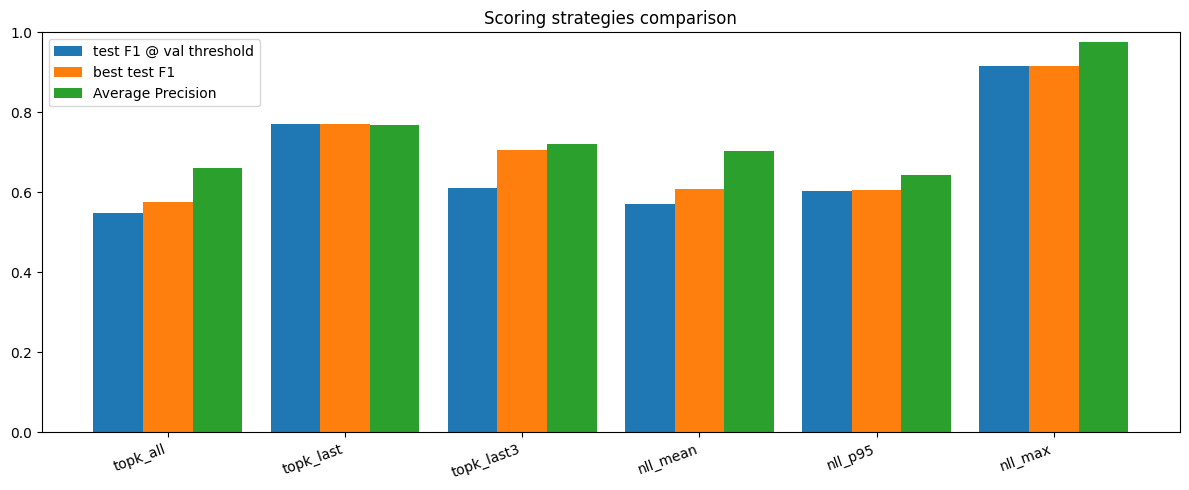

In [23]:
score_names = [row["score"] for row in score_results]
test_f1_at_val = np.array([row["test_f1_at_val_thr"] for row in score_results])
test_best_f1 = np.array([row["test_best_f1"] for row in score_results])
test_ap_scores = np.array([row["test_ap"] for row in score_results])

x = np.arange(len(score_names))
width = 0.28

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width, test_f1_at_val, width, label="test F1 @ val threshold")
ax.bar(x, test_best_f1, width, label="best test F1")
ax.bar(x + width, test_ap_scores, width, label="Average Precision")
ax.set_xticks(x, labels=score_names, rotation=20, ha="right")
ax.set_ylim(0, max(1.0, float(max(test_best_f1.max(), test_ap_scores.max()))))
ax.set_title("Scoring strategies comparison")
ax.legend()
plt.tight_layout()
plt.show()

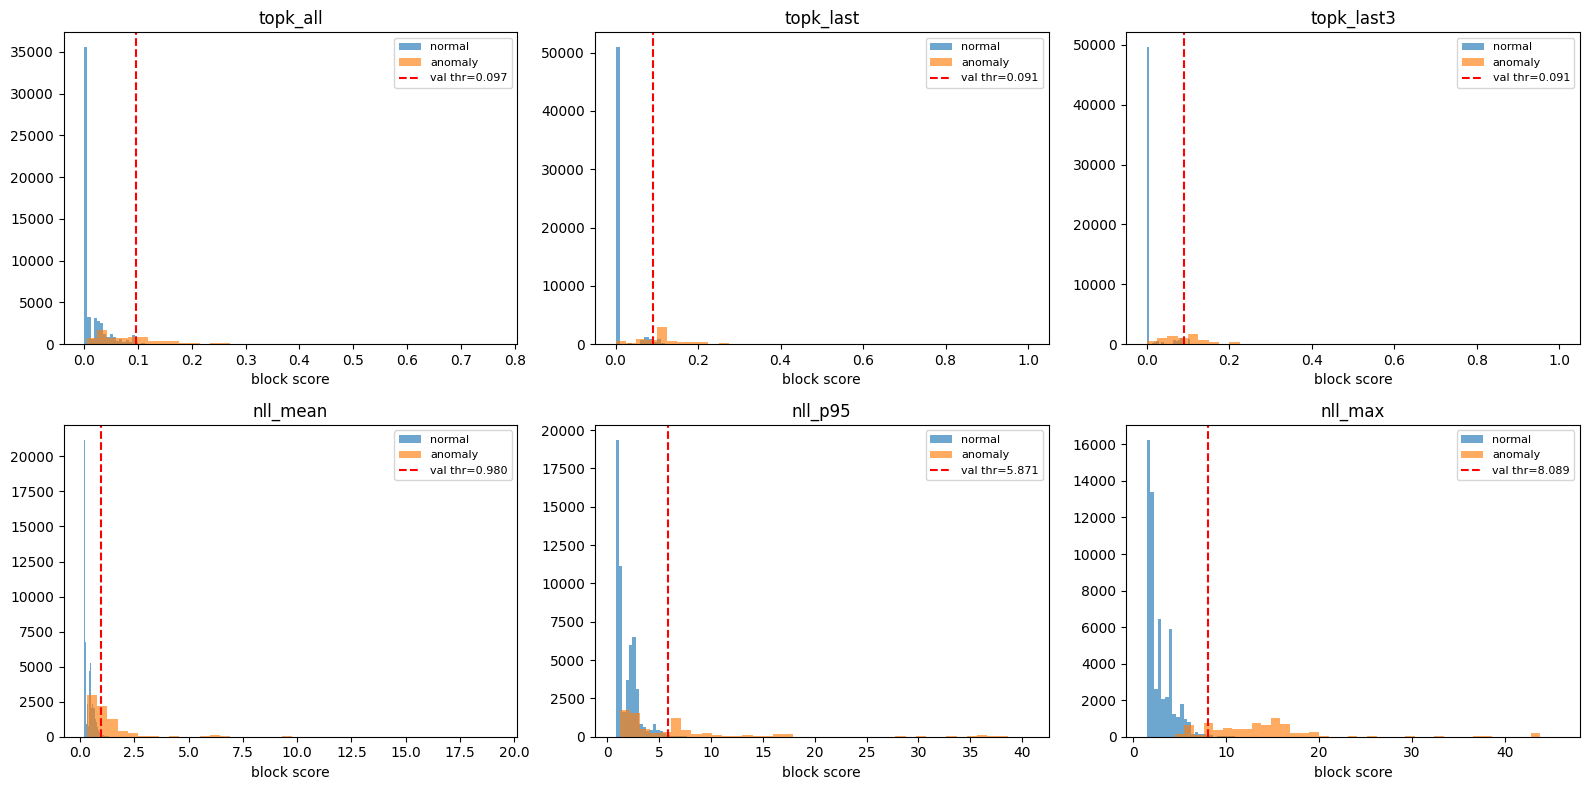

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()

for ax, name in zip(axes, score_names):
    score_map = score_maps[name]["test"]
    labels_arr, scores_arr = labels_scores_arrays(score_map, test_label_map)
    thr = next(row["val_best_thr"] for row in score_results if row["score"] == name)
    ax.hist(scores_arr[labels_arr == 0], bins=40, alpha=0.65, label="normal")
    ax.hist(scores_arr[labels_arr == 1], bins=40, alpha=0.65, label="anomaly")
    ax.axvline(thr, color="red", linestyle="--", label=f"val thr={thr:.3f}")
    ax.set_title(name)
    ax.set_xlabel("block score")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### Анализ стратегий

- `topk_last` близок к старой LSTM по f1-score - хоть модель и обучалась на всех позициях окна, такая стратегия подсчета score возвращает задачу к почти one-step next-event prediction
- `topk_all`, `topk_last3`, `nll_mean`, `nll_p95` хуже по f1-score - подсчет score такими способами "размазывает" сигнал аномальности, так как на него теперь влияет значительно больше значений в рамках одного блока
- `nll_max` значительно лучше по f1-score, чем бейзлайн - аномальный блок может почти полностью состоять из "нормальных" событий и иметь несколько "аномальных", данная стратегия ловит пик (если хотябы одно событие получило очень низкую вероятность, то anomaly score становится высоким)

### Итоговая таблица и выбранный score

Для финального сравнения используем threshold, подобранный только на validation. Колонка `test_best_f1` оставлена как диагностическая верхняя оценка, но не используется для выбора рабочего порога.

In [25]:
final_table = (
    pd.DataFrame(score_results)[
        [
            "score",
            "val_best_thr",
            "val_best_f1",
            "test_precision_at_val_thr",
            "test_recall_at_val_thr",
            "test_f1_at_val_thr",
            "test_fpr_at_val_thr",
            "test_ap",
            "test_best_f1",
        ]
    ]
    .rename(
        columns={
            "val_best_thr": "val_threshold",
            "val_best_f1": "val_f1",
            "test_precision_at_val_thr": "test_precision",
            "test_recall_at_val_thr": "test_recall",
            "test_f1_at_val_thr": "test_f1",
            "test_fpr_at_val_thr": "test_fpr",
            "test_ap": "average_precision",
        }
    )
    .sort_values("test_f1", ascending=False)
)

styled_table = final_table.style.format(
    {
        "val_threshold": "{:.4f}",
        "val_f1": "{:.3f}",
        "test_precision": "{:.3f}",
        "test_recall": "{:.3f}",
        "test_f1": "{:.3f}",
        "test_fpr": "{:.4f}",
        "average_precision": "{:.3f}",
        "test_best_f1": "{:.3f}",
    }
)

display(styled_table)

selected = final_table.iloc[0]
print("Selected score:", selected["score"])
print(f"Validation threshold: {selected['val_threshold']:.4f}")
print(
    "Test metrics: "
    f"precision={selected['test_precision']:.3f}, "
    f"recall={selected['test_recall']:.3f}, "
    f"f1={selected['test_f1']:.3f}, "
    f"fpr={selected['test_fpr']:.4f}, "
    f"AP={selected['average_precision']:.3f}"
)

,score,val_threshold,val_f1,test_precision,test_recall,test_f1,test_fpr,average_precision,test_best_f1
5,nll_max,8.0894,0.890,0.960,0.877,0.917,0.0049,0.975,0.915
1,topk_last,0.0909,0.668,0.785,0.756,0.770,0.0277,0.767,0.770
2,topk_last3,0.0909,0.519,0.726,0.528,0.612,0.0267,0.722,0.706
4,nll_p95,5.8709,0.603,0.934,0.446,0.604,0.0042,0.642,0.606
3,nll_mean,0.9802,0.531,0.836,0.432,0.570,0.0114,0.704,0.609
0,topk_all,0.0970,0.521,0.852,0.405,0.549,0.0095,0.661,0.576


Selected score: nll_max
Validation threshold: 8.0894
Test metrics: precision=0.960, recall=0.877, f1=0.917, fpr=0.0049, AP=0.975


### Финальный вывод

В Checkpoint 6 была проверена LSTM many-to-many next-token модель. Наивная агрегация `topk_all` ухудшила качество, потому что усредняет ошибки по всем позициям и размывает редкие аномальные переходы.

Лучшей стратегией оказался `nll_max`: максимальный `-log P(true_next_token)` по блоку. Это означает, что модель считает блок аномальным, если внутри него есть хотя бы один резко неожиданный переход.